In [82]:
import pickle
import numpy as np
import mne
import matplotlib.pyplot as plt
with open("E:\\koorathota_data\\pkl_data\\pkl_data\\pkl_data\\Copy of 08_26_2022_11_53_52-Exp_adadrive-Sbj_12-Ssn_02.dats-028.pkl", "rb") as f:
    data = pickle.load(f)

In [83]:
eye = data['Unity_ViveSREyeTracking'][0]
eye_timestamps =data['Unity_ViveSREyeTracking'][1]

In [177]:
pupilDiameterL = eye[0]
pupilDiameterR= eye[1]
openessL = eye[2]
openessR =eye[3]
gazeDxL=eye[4]
gazeDyL=eye[5]
gazeDzL=eye[6]
gazeDxR=eye[7]
gazeDyR=eye[8]
gazeDzR=eye[9]

In [14]:
print(max(gazeDxL),min(gazeDxL),np.mean(gazeDxL))
print(max(pupilDiameterL),min(pupilDiameterL),np.mean(pupilDiameterL))
print(max(openessL),min(openessL),np.mean(openessL))

0.53350830078125 -0.4505767822265625 0.0029096253464685755
4.0233306884765625 -1.0 1.945203471014082
1.0 0.0 0.9258187187254231


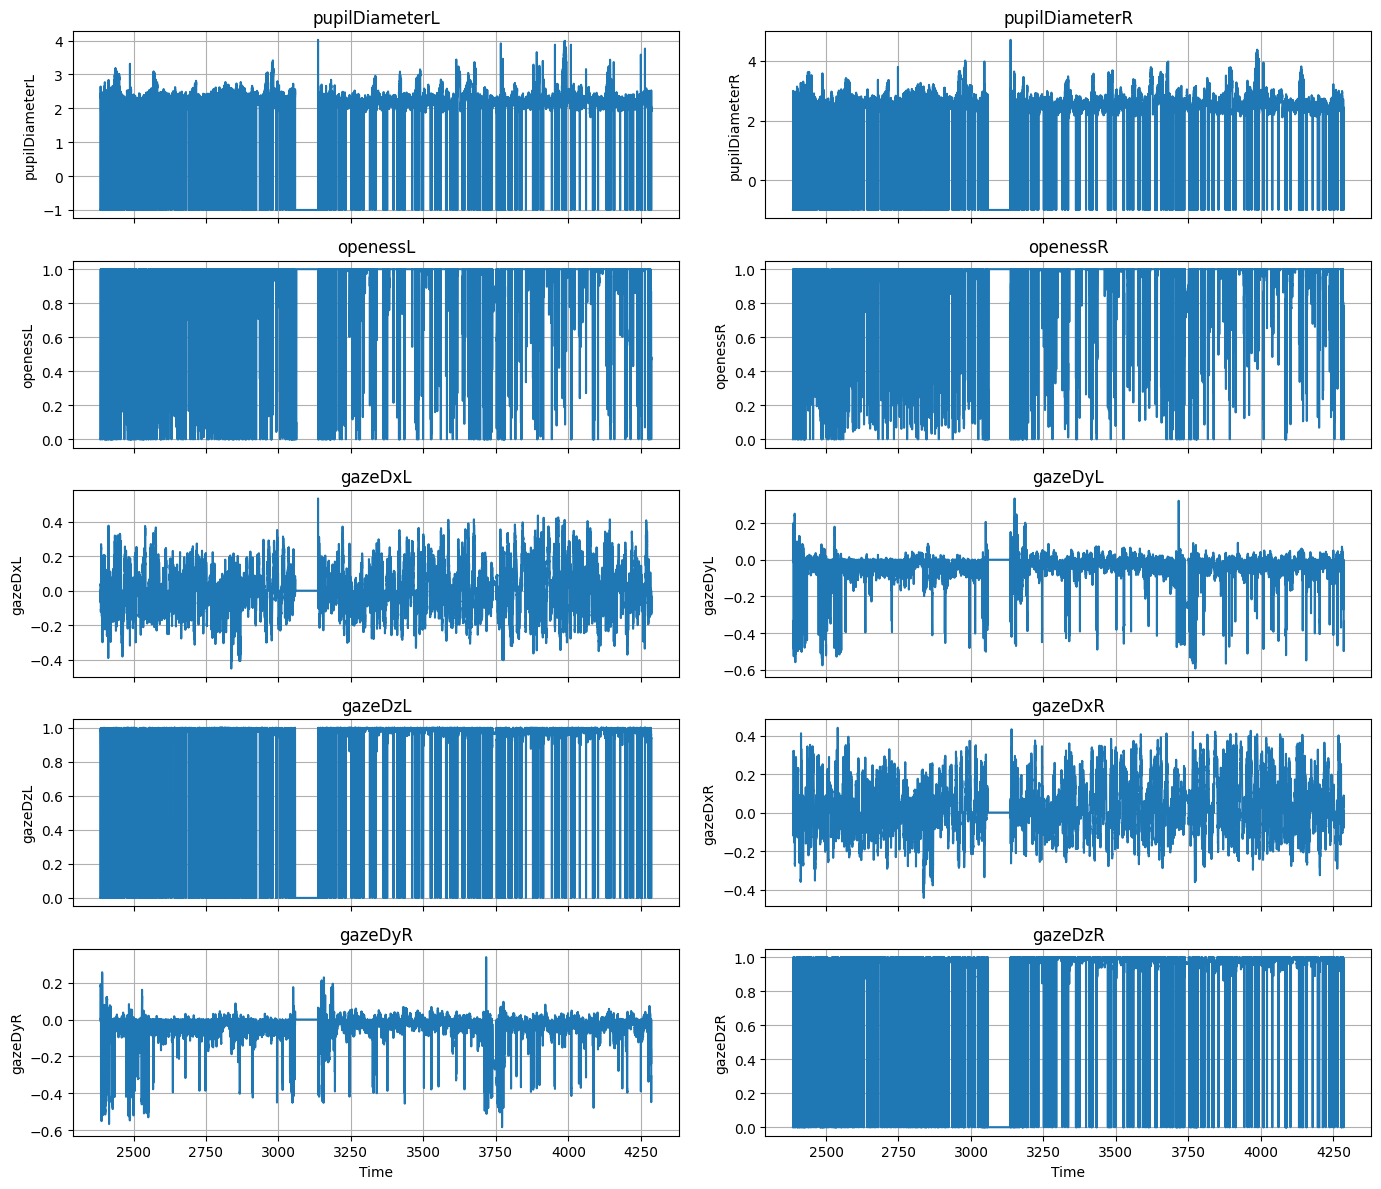

In [8]:
fig, axs = plt.subplots(5, 2, figsize=(14, 12), sharex=True)
axs = axs.ravel()

signals = [
    ("pupilDiameterL", pupilDiameterL),
    ("pupilDiameterR", pupilDiameterR),
    ("openessL", openessL),
    ("openessR", openessR),
    ("gazeDxL", gazeDxL),
    ("gazeDyL", gazeDyL),
    ("gazeDzL", gazeDzL),
    ("gazeDxR", gazeDxR),
    ("gazeDyR", gazeDyR),
    ("gazeDzR", gazeDzR),
]

for ax, (name, y) in zip(axs, signals):
    ax.plot(eye_timestamps, y)
    ax.set_title(name)
    ax.set_ylabel(name)
    ax.grid(True)

for ax in axs[-2:]:
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

In [11]:
dt = np.diff(eye_timestamps)
print("dt min/max/median:", dt.min(), dt.max(), np.median(dt))

dt min/max/median: 0.00831587237507847 0.008385576617001789 0.008331603745318716


In [73]:
bad_pupil = pupilDiameterL < 0
blink = openessL == 0

print("bad pupil samples:", np.sum(bad_pupil))
print("blink samples:", np.sum(blink))

if np.sum(bad_pupil) > 0:
    print("fraction of bad pupil samples during blink:",
          np.mean(blink[bad_pupil]))

if np.sum(blink) > 0:
    print("fraction of blink samples with bad pupil:",
          np.mean(bad_pupil[blink]))

bad pupil samples: 19112
blink samples: 2336
fraction of bad pupil samples during blink: 0.1209187944746756
fraction of blink samples with bad pupil: 0.9892979452054794


In [172]:
import numpy as np

def dilation_speed(t_s, d):
    d = np.asarray(d, float)
    

    dspeed = np.full(len(d), np.nan)
    for i in range(len(d)):
        vals = []

        if i > 0 and np.isfinite(d[i]) and np.isfinite(d[i-1]) and t_s[i] != t_s[i-1]:
            vals.append(abs(d[i] - d[i-1]) / abs(t_s[i] - t_s[i-1]))

        if i < len(d)-1 and np.isfinite(d[i]) and np.isfinite(d[i+1]) and t_s[i+1] != t_s[i]:
            vals.append(abs(d[i+1] - d[i]) / abs(t_s[i+1] - t_s[i]))

        if vals:
            dspeed[i] = max(vals)

    return dspeed

def mad_threshold(x, n=16):
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    return med + n * mad

def find_nan_runs(mask):
    """
    Find contiguous True runs in a boolean mask.
    Returns list of (start_idx, end_idx) inclusive.
    """
    starts =[]
    ends=[]
    for i in range(len(mask)):
        if i== 0 and mask[i]:
            starts.append(i)
        elif mask[i] and not mask[i-1]:
            starts.append(i)
        if i==len(mask)-1 and mask[i]:
            ends.append(i)
        elif i <len(mask)-1 and mask[i] and not mask[i+1]:
            ends.append(i)
    return list(zip(starts, ends))


def merge_close_gaps(mask, t_s, max_separation_s=0.100):
    """
    Merge NaN gaps if the valid chunk between them is shorter than max_separation_ms.
    """
    mask = np.asarray(mask, dtype=bool).copy()
   

    runs = find_nan_runs(mask)
    if len(runs) < 2:
        return mask

    merged_mask = mask.copy()
    current_start, current_end = runs[0]

    for next_start, next_end in runs[1:]:
        separation_s = t_s[next_start] - t_s[current_end]

        if separation_s < max_separation_s:
            merged_mask[current_start:next_end + 1] = True
            current_end = next_end
        else:
            current_start, current_end = next_start, next_end

    return merged_mask


def pad_blink_gaps(mask, t_s, min_gap_s=0.075, max_gap_s=0.500,
                    pad_before_s=0.050, pad_after_s=0.050):
    """
    For gaps with duration > min_gap_ms and < max_gap_ms,
    extend the mask by pad_before_ms before and pad_after_ms after.
    """
    mask = np.asarray(mask, dtype=bool).copy()
    
    runs = find_nan_runs(mask)
    padded_mask = mask.copy()

    for start, end in runs:
        gap_duration_s = t_s[end] - t_s[start]

        if (gap_duration_s >= min_gap_s): #and (gap_duration_ms <= max_gap_ms):
            start_time = t_s[start] - pad_before_s
            end_time = t_s[end] + pad_after_s
            extra = (t_s >= start_time) & (t_s <= end_time)
            padded_mask[extra] = True

    return padded_mask


import numpy as np
from scipy.interpolate import CubicSpline

def interpolate_short_gaps_cubic(t_s, y, max_gap_s=0.040):
    """
    Interpolate NaN gaps shorter than max_gap_ms using cubic spline,
    with 2 valid points before and 2 valid points after the gap.
    """
   
    y = np.asarray(y, dtype=float).copy()
    t_s = np.asarray(t_s, dtype=float)
    nan_mask = np.isnan(y)
    runs = find_nan_runs(nan_mask)

    for start, end in runs:
        gap_duration_s = t_s[end] - t_s[start]

        if gap_duration_s < max_gap_s:
            left1 = start - 1
            left2 = start - 2
            right1 = end + 1
            right2 = end + 2

            # check bounds
            if left2 >= 0 and right2 < len(y):
                # check support points are finite
                if (
                    np.isfinite(y[left2]) and
                    np.isfinite(y[left1]) and
                    np.isfinite(y[right1]) and
                    np.isfinite(y[right2])
                ):
                    # time points must be ordered
                    x_t = [t_s[left2], t_s[left1], t_s[right1], t_s[right2]]
                    y_t = [y[left2], y[left1], y[right1], y[right2]]

                    # extra safety: strictly increasing x
                    if np.all(np.diff(x_t) > 0):
                        cs = CubicSpline(x_t, y_t, bc_type='natural')
                        y[start:end+1] = cs(t_s[start:end+1])

    return y


def preprocess_pupil_gaps(t_s, pupil_with_blinks):
    """
    Full gap-processing stage:
    1) merge close gaps
    2) pad medium-sized gaps
    3) interpolate only short gaps
    """
    t_s = np.asarray(t_s, dtype=float)
    pupil_with_nans = np.asarray(pupil_with_blinks, dtype=float)

    initial_nan_mask = np.isnan(pupil_with_nans)

    merged_mask = merge_close_gaps(
        initial_nan_mask, t_s )

    padded_mask = pad_blink_gaps(
        merged_mask, t_s)

    pupil_after_masking = pupil_with_nans.copy()
    pupil_after_masking[padded_mask] = np.nan

    pupil_interpolated = interpolate_short_gaps_cubic( t_s, pupil_after_masking )

    return {
        "initial_nan_mask": initial_nan_mask,
        "merged_mask": merged_mask,
        "padded_mask": padded_mask,
        "pupil_after_masking": pupil_after_masking,
        "pupil_interpolated": pupil_interpolated,
    }

In [178]:
import numpy as np

pupil = np.array(pupilDiameterL, dtype=float)
openness = np.array(openessL, dtype=float)

blink = openness == 0
invalid = (pupil <= 0) | blink

pupil_mask = pupil.copy()
pupil_mask[invalid] = np.nan
spd = dilation_speed(eye_timestamps, pupil_mask)
thr = mad_threshold(spd, n=16)
speed_outlier = spd > thr
pupil_blink = pupil_mask.copy()
pupil_blink[speed_outlier] = np.nan
result = preprocess_pupil_gaps(
    eye_timestamps,
    pupil_blink)
pupil_clean = result['pupil_interpolated']

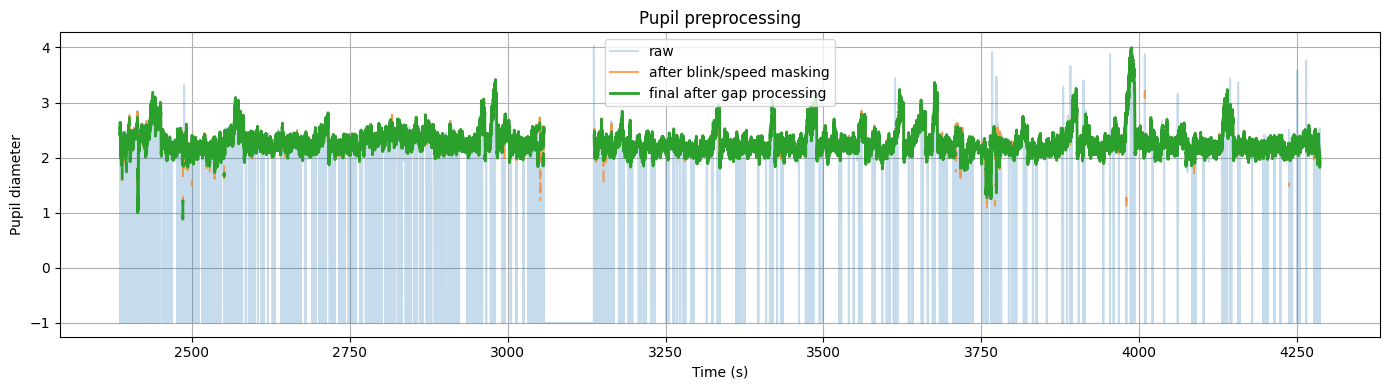

In [179]:
plt.figure(figsize=(14, 4))
plt.plot(eye_timestamps, pupil, alpha=0.25, label="raw")
plt.plot(eye_timestamps, pupil_blink, alpha=0.7, label="after blink/speed masking")
plt.plot(eye_timestamps, pupil_clean, linewidth=2, label="final after gap processing")
plt.xlabel("Time (s)")
plt.ylabel("Pupil diameter")
plt.title("Pupil preprocessing")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

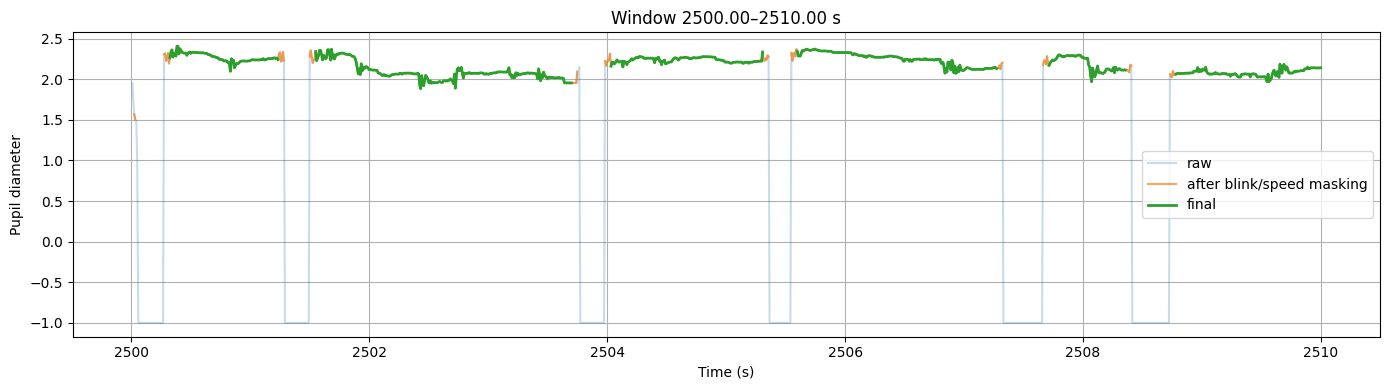

In [180]:
start_s = 2500.000
end_s = 2510.000
win = (eye_timestamps >= start_s) & (eye_timestamps <= end_s)

plt.figure(figsize=(14, 4))
plt.plot(eye_timestamps[win], pupil[win], alpha=0.25, label="raw")
plt.plot(eye_timestamps[win], pupil_blink[win], alpha=0.7, label="after blink/speed masking")
plt.plot(eye_timestamps[win], pupil_clean[win], linewidth=2, label="final")
plt.xlabel("Time (s)")
plt.ylabel("Pupil diameter")
plt.title(f"Window {start_s:.2f}–{end_s:.2f} s")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def check_n_values(t_s, pupil, openness, n_values, start_s, end_s):
    pupil = np.asarray(pupil, float)
    openness = np.asarray(openness, float)
    t_s = np.asarray(t_s, float)

    base_mask = (pupil <= 0) | (openness == 0)

    pupil1 = pupil.copy()
    pupil1[base_mask] = np.nan

    spd = dilation_speed(t_s, pupil1)

    win = (t_s >= start_s) & (t_s <= end_s)

    for n in n_values:
        thr = mad_threshold(spd, n=n)
        speed_outlier = spd > thr

        pupil2 = pupil1.copy()
        pupil2[speed_outlier] = np.nan

        rejected_frac = np.mean(speed_outlier[np.isfinite(spd)])

        print(f"n={n}, threshold={thr:.6f}, speed-rejected fraction={rejected_frac:.4f}")

        plt.figure(figsize=(14, 4))
        plt.plot(t_s[win], pupil[win], alpha=0.35, label="raw")
        plt.plot(t_s[win], pupil2[win], label=f"cleaned, n={n}")
        plt.scatter(
            t_s[win&speed_outlier ],
            pupil[win&speed_outlier],
            s=12,
            label="speed outlier"
        )
        plt.title(f"Check n={n}")
        plt.xlabel("Time (ms)")
        plt.ylabel("Pupil diameter")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

n=5, threshold=0.007724, speed-rejected fraction=0.1573


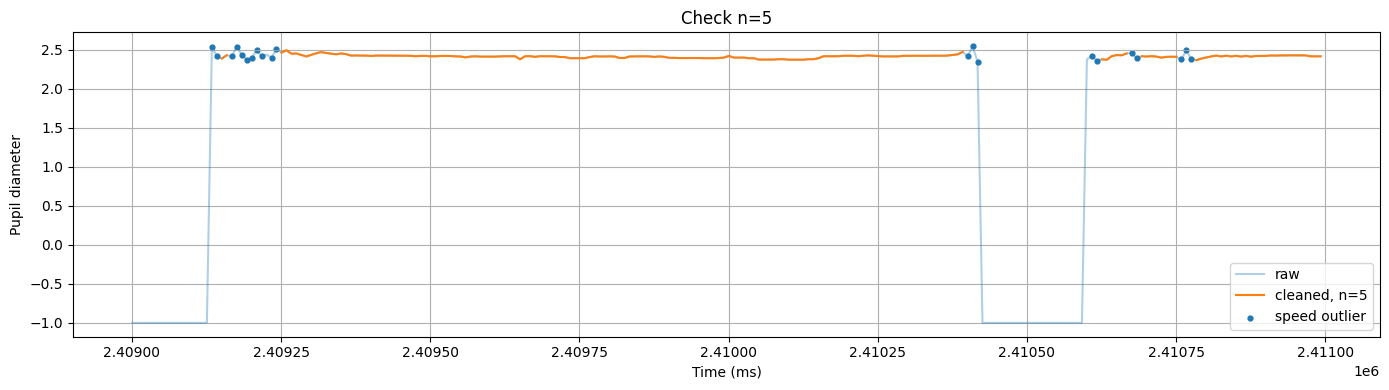

n=8, threshold=0.011500, speed-rejected fraction=0.0770


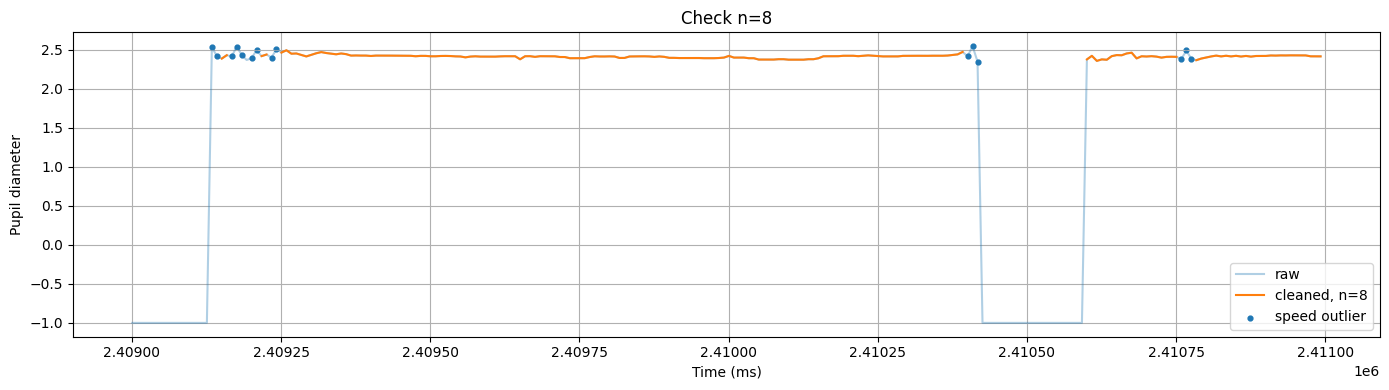

n=12, threshold=0.016533, speed-rejected fraction=0.0261


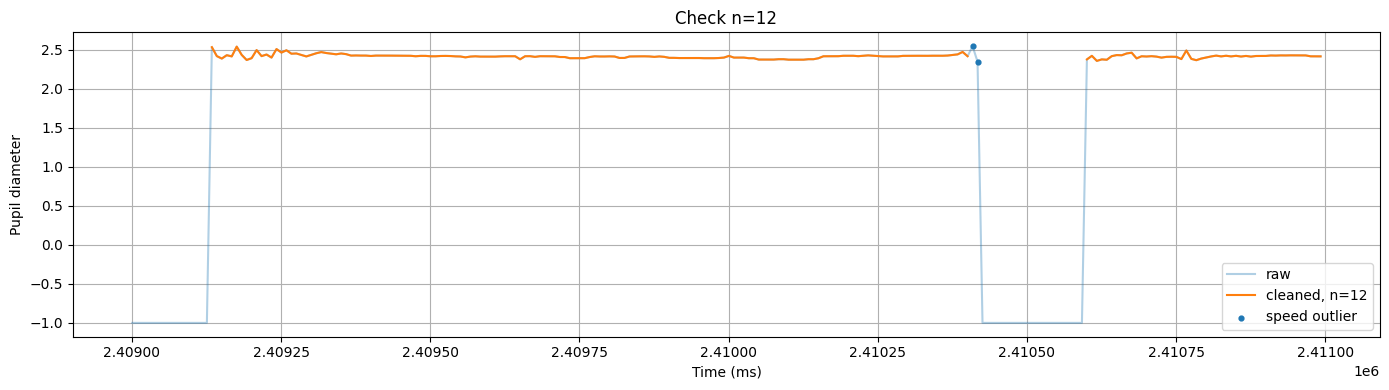

n=16, threshold=0.021567, speed-rejected fraction=0.0085


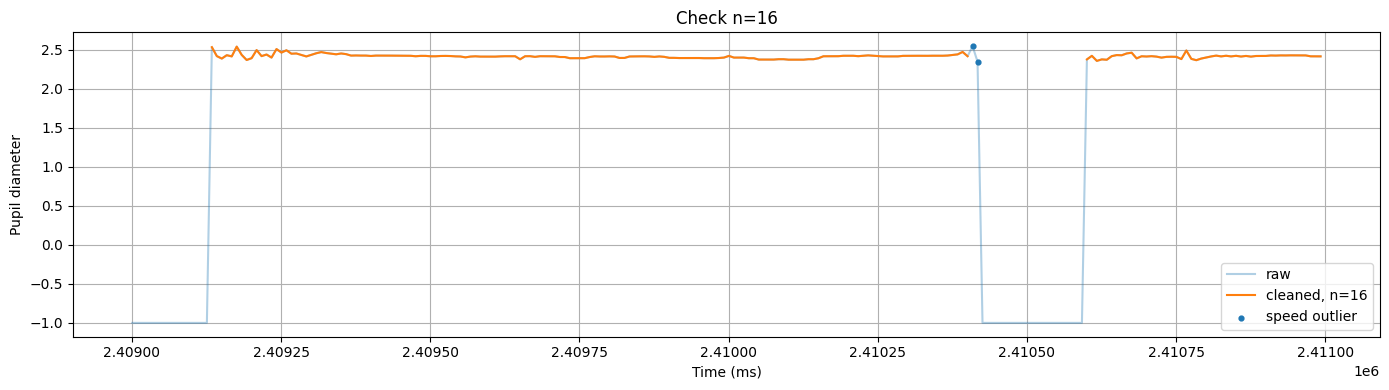

n=20, threshold=0.026601, speed-rejected fraction=0.0036


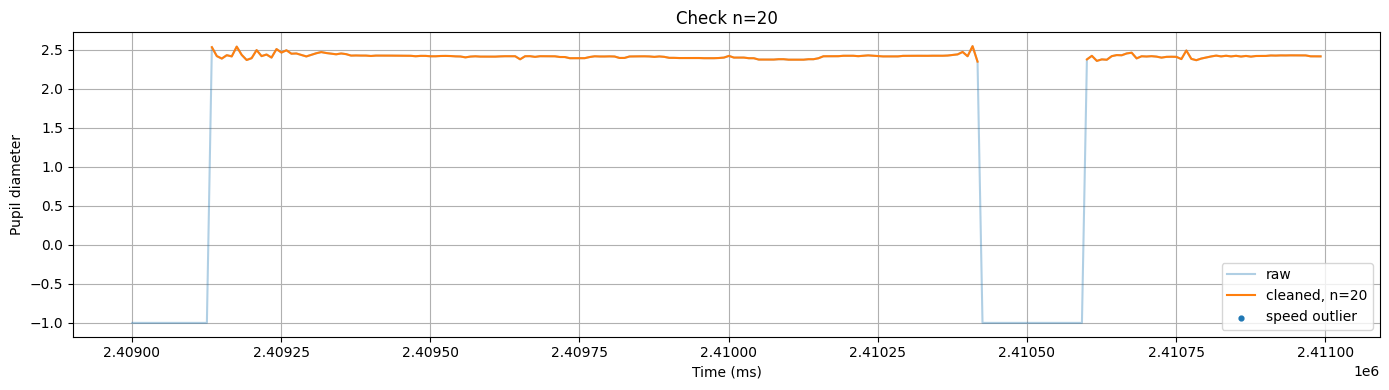

In [90]:

check_n_values(
    t_s=eye_timestamps,
    pupil=pupilDiameterL,
    openness=openessL,
    n_values=[5,8, 12, 16, 20],
    start_s=2409.000,
    end_s=2411.000
)

In [144]:
from scipy.interpolate import interp1d 
def resample_to_uniform_grid(eye_timestamps, signal, target_hz=120):
    """
    Resample an irregularly sampled signal to a uniform grid.
    NaN gaps are preserved — don't interpolate across them.
    """
    eye_t= 1.0 / target_hz
    t_uniform = np.arange(eye_timestamps[0], eye_timestamps[-1], eye_t)

    # Only interpolate over finite segments
    finite_mask = np.isfinite(signal)
    if finite_mask.sum() < 2:
        return t_uniform, np.full(len(t_uniform), np.nan)

    # Interpolate only within finite regions
    f = interp1d(
        eye_timestamps[finite_mask], signal[finite_mask],
        kind='linear',
        bounds_error=False,
        fill_value=np.nan  # NaN outside known data = preserves gaps
    )
    return t_uniform, f(t_uniform)

In [203]:
t_uniform, resampled_pupil =resample_to_uniform_grid(eye_timestamps,pupil_clean)

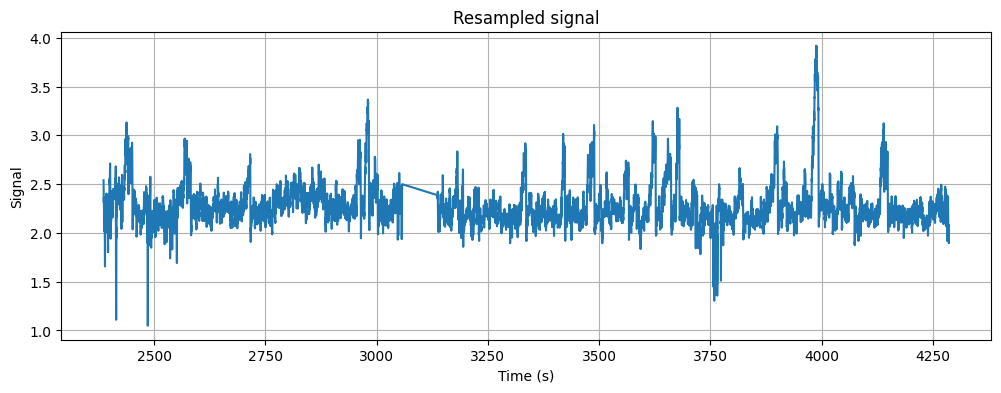

In [212]:
plt.figure(figsize=(12, 4))
plt.plot(t_uniform, resampled_pupil)
plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("Resampled signal")
plt.grid(True)
plt.show()

In [187]:
import numpy as np

pupil = np.array(pupilDiameterR, dtype=float)
openness = np.array(openessR, dtype=float)

blink = openness == 0
invalid = (pupil <= 0) | blink

pupil_mask = pupil.copy()
pupil_mask[invalid] = np.nan
spd = dilation_speed(eye_timestamps, pupil_mask)
thr = mad_threshold(spd, n=16)
speed_outlier = spd > thr
pupil_blink = pupil_mask.copy()
pupil_blink[speed_outlier] = np.nan
result = preprocess_pupil_gaps(
    eye_timestamps,
    pupil_blink)
pupil_cleanR = result['pupil_interpolated']

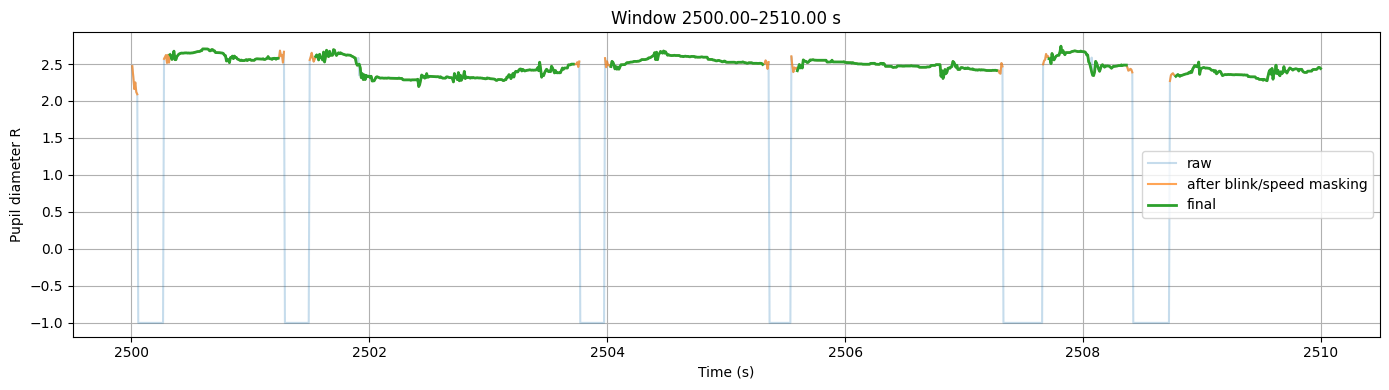

In [188]:
start_s = 2500.000
end_s = 2510.000
win = (eye_timestamps >= start_s) & (eye_timestamps <= end_s)

plt.figure(figsize=(14, 4))
plt.plot(eye_timestamps[win], pupil[win], alpha=0.25, label="raw")
plt.plot(eye_timestamps[win], pupil_blink[win], alpha=0.7, label="after blink/speed masking")
plt.plot(eye_timestamps[win], pupil_cleanR[win], linewidth=2, label="final")
plt.xlabel("Time (s)")
plt.ylabel("Pupil diameter R")
plt.title(f"Window {start_s:.2f}–{end_s:.2f} s")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [204]:
t_uniform, resampled_pupilR =resample_to_uniform_grid(eye_timestamps,pupil_cleanR)

In [ ]:
def create_mean_pupil_size_simple(pupil_cleanL, pupil_cleanR):
    pupil_cleanL = np.asarray(pupil_cleanL, dtype=float)
    pupil_cleanR = np.asarray(pupil_cleanR, dtype=float)

    pupil_mean = np.full(len(pupil_cleanL), np.nan)

    for i in range(len(pupil_cleanL)):
        if np.isfinite(pupil_cleanL[i]) and np.isfinite(pupil_cleanR[i]):
            pupil_mean[i] = np.mean([pupil_cleanL[i], pupil_cleanR[i]])
        elif np.isfinite(pupil_cleanL[i]) and np.isnan(pupil_cleanR[i]):
            pupil_mean[i] = pupil_cleanL[i]
        elif np.isnan(pupil_cleanL[i]) and np.isfinite(pupil_cleanR[i]):
            pupil_mean[i] = pupil_cleanR[i]

    return pupil_mean

In [190]:
import numpy as np

def create_mean_pupil_size_offset(t_s, pupil_cleanL, pupil_cleanR):
    t_s = np.asarray(t_s, dtype=float)
    L = np.asarray(pupil_cleanL, dtype=float)
    R = np.asarray(pupil_cleanR, dtype=float)

    mean_pupil = np.full(len(L), np.nan)

    both = np.isfinite(L) & np.isfinite(R)
    only_L = np.isfinite(L) & np.isnan(R)
    only_R = np.isnan(L) & np.isfinite(R)

    # plain mean when both exist
    mean_pupil[both] = (L[both] + R[both]) / 2.0

    # estimate dynamic offset where both are present
    offset = np.full(len(L), np.nan)
    offset[both] = L[both] - R[both]

    if np.sum(both) >= 2:
        offset_interp = np.interp(t_s, t_s[both], offset[both])
    else:
        offset_interp = np.full(len(L), np.nan)

    # if only left exists, estimate mean from left and offset
    # mean = (L + R)/2, with R ≈ L - offset
    mean_pupil[only_L] = L[only_L] - offset_interp[only_L] / 2.0

    # if only right exists, estimate mean from right and offset
    # L ≈ R + offset
    mean_pupil[only_R] = R[only_R] + offset_interp[only_R] / 2.0

    return mean_pupil

In [207]:
mean_pupil = create_mean_pupil_size_offset(eye_timestamps,pupil_clean,pupil_cleanR)

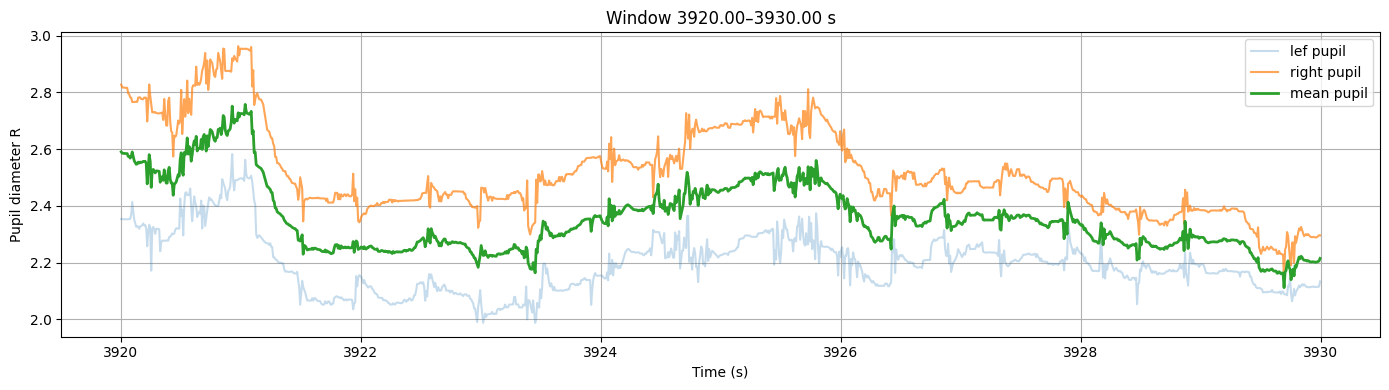

In [217]:
start_s = 3920.000
end_s = 3930.000
win = (eye_timestamps >= start_s) & (eye_timestamps <= end_s)

plt.figure(figsize=(14, 4))
plt.plot(eye_timestamps[win], pupil_clean[win], alpha=0.25, label="lef pupil")
plt.plot(eye_timestamps[win], pupil_cleanR[win], alpha=0.7, label="right pupil")
plt.plot(eye_timestamps[win], mean_pupil[win], linewidth=2, label="mean pupil")
plt.xlabel("Time (s)")
plt.ylabel("Pupil diameter R")
plt.title(f"Window {start_s:.2f}–{end_s:.2f} s")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [209]:
t_uniform, resampled_pupil_mean =resample_to_uniform_grid(eye_timestamps,mean_pupil)
t_uniform, resampled_pupilR =resample_to_uniform_grid(eye_timestamps,pupil_cleanR)

In [184]:
from scipy.signal import butter, filtfilt
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    finite = np.isfinite(data)
    starts =[]
    ends=[]
    for i in range(len(finite)):
        if i== 0 and finite[i]:
            starts.append(i)
        elif finite[i] and not finite[i-1]:
            starts.append(i)
        if i==len(finite)-1 and finite[i]:
            ends.append(i)
        elif i <len(finite)-1 and finite[i] and not finite[i+1]:
            ends.append(i)
    for s, e in zip(starts, ends):
        segment = data[s:e]
        # Need at least 3x filter order samples to avoid edge issues
        if len(segment) > 3 * order:
            data[s:e] = filtfilt(b, a, segment)

    return data

In [210]:
pupil_filteredL = butter_lowpass_filter(resampled_pupil, cutoff=4, fs=120, order=4)
pupil_filteredR = butter_lowpass_filter(resampled_pupilR, cutoff=4, fs=120, order=4)
pupil_filteredM = butter_lowpass_filter(resampled_pupil_mean, cutoff=4, fs=120, order=4)

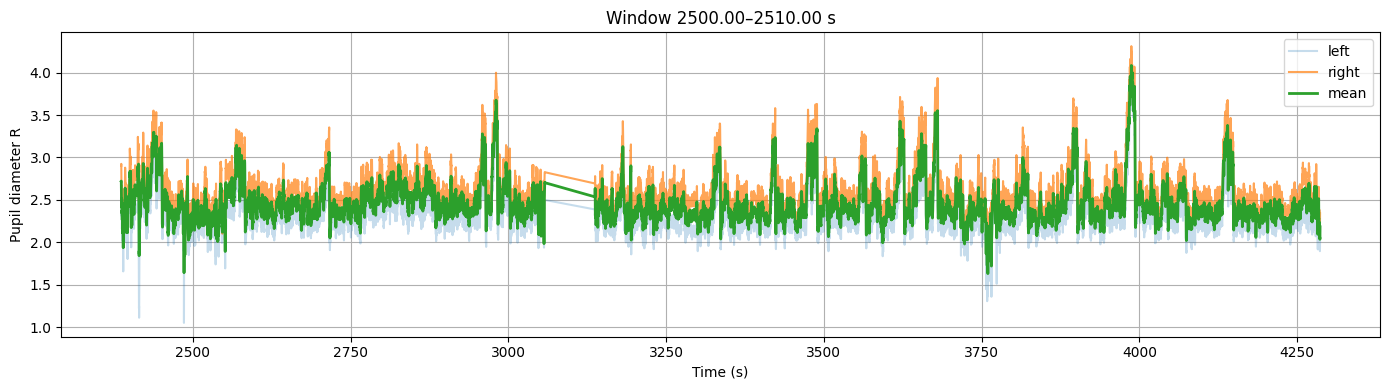

In [213]:
plt.figure(figsize=(14, 4))
plt.plot(t_uniform, pupil_filteredL, alpha=0.25, label="left")
plt.plot(t_uniform, pupil_filteredR, alpha=0.7, label="right")
plt.plot(t_uniform, pupil_filteredM, linewidth=2, label="mean")
plt.xlabel("Time (s)")
plt.ylabel("Pupil diameter R")
plt.title(f"Window {start_s:.2f}–{end_s:.2f} s")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [170]:
def zscore_finite(signal):
    signal = np.asarray(signal, float).copy()
    finite_vals = signal[np.isfinite(signal)]
    if len(finite_vals) < 2:
        return signal
    mean = finite_vals.mean()
    std = finite_vals.std()
    if std < 1e-8:
        return signal - mean
    return (signal - mean) / std




In [214]:
pupil_normL   = zscore_finite(pupil_filteredL)
pupil_normR   = zscore_finite(pupil_filteredR)
pupil_normM   = zscore_finite(pupil_filteredM)

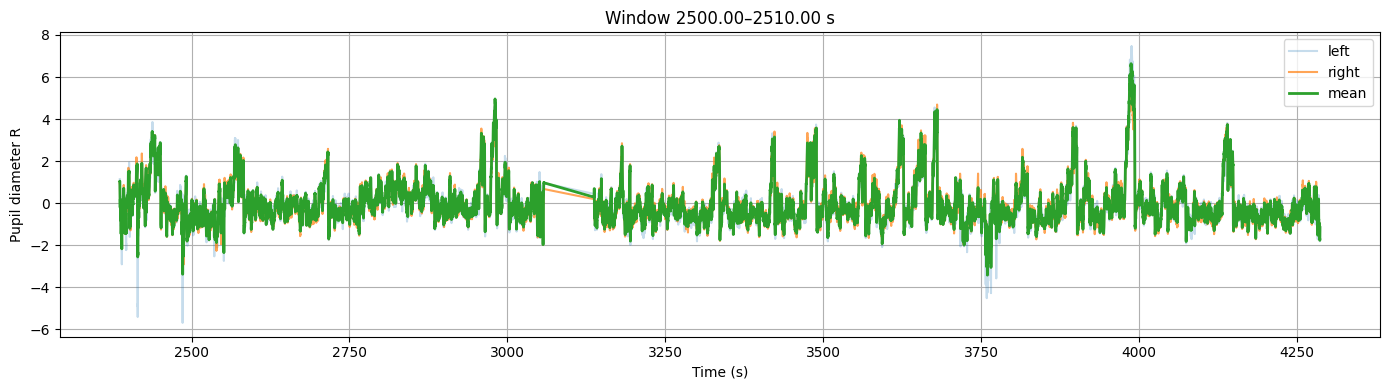

In [215]:
plt.figure(figsize=(14, 4))
plt.plot(t_uniform, pupil_normL, alpha=0.25, label="left")
plt.plot(t_uniform, pupil_normR, alpha=0.7, label="right")
plt.plot(t_uniform, pupil_normM, linewidth=2, label="mean")
plt.xlabel("Time (s)")
plt.ylabel("Pupil diameter R")
plt.title(f"Window {start_s:.2f}–{end_s:.2f} s")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()